# Import statements

In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
#import pickle

%matplotlib inline

In [2]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf


In [3]:
import json


In [4]:
# https://github.com/ipython/ipython/issues/10627
import os
os.environ['QT_QPA_PLATFORM']='offscreen'

import ete3 as ETE

from ete3 import Tree


### Import custom functions

In [5]:
#from gcutils.general import parse_PAFtools_VarTSV, label_DF_ByOvrLapGenes, label_PAF_DF_ByOvrLapGenes'

#from gcutils.gubbinsfuncs import get_RecombEvents_From_Gubbins_GFF, parse_BaseReconstruction_EMBL_Gubbins

### Set matplotlib text export settings for Adobe Illustrator

In [6]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

#### Pandas Viewing Settings

In [7]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

### Link to ETE3 documentation for tree layout style
 http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#interactive-visualization-of-trees

In [8]:
LinToColor_Dict = {"lineage1": "#DF83AC",
                   "lineage2": "#7098CB",
                   "lineage3": "#815D9F",
                   "lineage4": "#E76956",
                   "lineage5": "#B67548",
                   "lineage6": "#6AB79E",
                   "lineage8": "#E4515B", 
                   "None": "black",}


In [9]:


def Mtb_ColorBranchByLineage_Layout(node):
    F = ETE.TextFace(node.name, fsize=2)
    if node.is_leaf():
        #NameAnd_Lineage_Text =  f"  {node.name} {node.Mtb_lineage}"
        #F_NameAndLineage = ETE.TextFace(NameAnd_Lineage_Text, fsize=3)
        
        #ETE.add_face_to_node(F_NameAndLineage, node, column=0, position="branch-right")

        
        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
        nstyle["fgcolor"] = "black"
        nstyle["size"] = 1
        
        Node_PrimaryLin = node_To_PrimaryLin_Dict.get(node.name, "None")
        
        nstyle["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
          
        node.set_style(nstyle)
        node.margin_left = 10        
    else: 
        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
        nstyle["fgcolor"] = "black"
        nstyle["size"] = 0
        
        Node_PrimaryLin = node_To_PrimaryLin_Dict.get(node.name, "None")
        
        nstyle["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        
        node.set_style(nstyle)

ts_3 = ETE.TreeStyle()
ts_3.show_leaf_name = False
ts_3.show_branch_length = False
ts_3.show_branch_support = False
ts_3.show_scale = True #True
ts_3.branch_vertical_margin = 2
ts_3.layout_fn = Mtb_ColorBranchByLineage_Layout
ts_3.rotation = 90

ts_3_circ = ETE.TreeStyle()
ts_3_circ.mode = "c" # draw tree in circular mode
ts_3_circ.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_3_circ.arc_span = 180
ts_3_circ.show_leaf_name = False
ts_3_circ.show_branch_length = False
ts_3_circ.show_branch_support = False
ts_3_circ.show_scale = True #True
ts_3_circ.branch_vertical_margin = 2
ts_3_circ.layout_fn = Mtb_ColorBranchByLineage_Layout


ts_ColLin = ETE.TreeStyle()
ts_ColLin.show_leaf_name = False
ts_ColLin.show_branch_length = False
ts_ColLin.show_branch_support = False
ts_ColLin.show_scale = True #True
ts_ColLin.branch_vertical_margin = 2
ts_ColLin.layout_fn = Mtb_ColorBranchByLineage_Layout
ts_ColLin.rotation = 90

ts_ColLin_circ = ETE.TreeStyle()
ts_ColLin_circ.mode = "c" # draw tree in circular mode
ts_ColLin_circ.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_ColLin_circ.arc_span = 180
ts_ColLin_circ.show_leaf_name = False
ts_ColLin_circ.show_branch_length = False
ts_ColLin_circ.show_branch_support = False
ts_ColLin_circ.show_scale = True #True
ts_ColLin_circ.branch_vertical_margin = 2
ts_ColLin_circ.layout_fn = Mtb_ColorBranchByLineage_Layout



ts_IQ_FullCirc = ETE.TreeStyle()
ts_IQ_FullCirc.mode = "c" # draw tree in circular mode
ts_IQ_FullCirc.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_IQ_FullCirc.arc_span = 355
ts_IQ_FullCirc.show_leaf_name = False
ts_IQ_FullCirc.show_branch_length = False
ts_IQ_FullCirc.show_branch_support = False
ts_IQ_FullCirc.show_scale = True #True
ts_IQ_FullCirc.branch_vertical_margin = 2
ts_IQ_FullCirc.layout_fn = Mtb_ColorBranchByLineage_Layout
ts_IQ_FullCirc.scale_length = 0.002


ts_5_HalfCirc = ETE.TreeStyle()
ts_5_HalfCirc.mode = "c" # draw tree in circular mode
ts_5_HalfCirc.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_5_HalfCirc.arc_span = 180
ts_5_HalfCirc.show_leaf_name = False
ts_5_HalfCirc.show_branch_length = False
ts_5_HalfCirc.show_branch_support = False
ts_5_HalfCirc.show_scale = False #True
ts_5_HalfCirc.branch_vertical_margin = 2
ts_5_HalfCirc.rotation = 0 #90

ts_5_FullCirc = ETE.TreeStyle()
ts_5_FullCirc.mode = "c" # draw tree in circular mode
ts_5_FullCirc.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_5_FullCirc.arc_span = 355
ts_5_FullCirc.show_leaf_name = False
ts_5_FullCirc.show_branch_length = False
ts_5_FullCirc.show_branch_support = False
ts_5_FullCirc.show_scale = False #True
ts_5_FullCirc.branch_vertical_margin = 2
ts_5_FullCirc.rotation = 0 #90

### Define ETE3 Node + Branch Labeling functions 

In [10]:
from ete3 import TextFace

def labelNodesByNumEvents(in_NodeToNumEventsDict, input_Tree):

    input_Tree_Labeled = input_Tree.copy()
        
    # Draws nodes as small red spheres of diameter equal to 10 pixels
    #i_nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
    #i_nstyle["shape"] = "sphere"
    #i_nstyle["size"] = 50
    #i_nstyle["fgcolor"] = "darkred" #"darkred"

    for n in input_Tree_Labeled.traverse():
        
        Node_NumEvents = in_NodeToNumEventsDict.get(n.name, 0)
    
        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style

        
        Node_PrimaryLin = node_To_PrimaryLin_Dict.get(n.name, "None")
        #n.img_style["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        #n.img_style["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        
        
        nstyle["size"] = 2 + (7 * Node_NumEvents)

        if Node_NumEvents > 0:
            nstyle["fgcolor"] = "red"
            #n.img_style["size"] = 15
            #n.img_style["color"] = "red"
            nstyle["vt_line_color"] = "#800080"
            nstyle["hz_line_color"] = "#800080"
            nstyle["vt_line_width"] = 50 
            nstyle["hz_line_width"] = 25
            
        if Node_NumEvents == 0:
            nstyle["fgcolor"] = "black"   
        

            
        n.set_style(nstyle)
        

    return input_Tree_Labeled




def labelNodesByNumEvents_V2(in_NodeToNumEventsDict, input_Tree):

    input_Tree_Labeled = input_Tree.copy()
        
    # Draws nodes as small red spheres of diameter equal to 10 pixels
    #i_nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
    #i_nstyle["shape"] = "sphere"
    #i_nstyle["size"] = 50
    #i_nstyle["fgcolor"] = "darkred" #"darkred"

    for n in input_Tree_Labeled.traverse():
        
        Node_NumEvents = in_NodeToNumEventsDict.get(n.name, 0)
    
        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style

        Node_PrimaryLin = node_To_PrimaryLin_Dict.get(n.name, "None")
        #n.img_style["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        #n.img_style["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["vt_line_width"] = 5
        nstyle["hz_line_width"] = 5
        
        nstyle["size"] = 2 + (7 * Node_NumEvents)

        if Node_NumEvents > 0:
            nstyle["fgcolor"] = "red"
            #n.img_style["size"] = 15
            #n.img_style["color"] = "red"
            nstyle["vt_line_color"] = "#800080"
            nstyle["hz_line_color"] = "#800080"
            nstyle["vt_line_width"] = 10 
            nstyle["hz_line_width"] = 10

            # Creates a sphere face whose size is proportional to node's
            # feature "weight"
            C = CircleFace(radius=40, color="purple", style="circle")
            # Let's make the sphere transparent
            C.opacity = 0.7
            # And place as a float face over the tree
            n.add_face(C, 0, position = "float")
        if Node_NumEvents == 0:
            nstyle["fgcolor"] = "black"   
        

            
        n.set_style(nstyle)
        

    return input_Tree_Labeled

### Dev Code to highlight specific branch(es) of the phylogeny

In [11]:
from ete3 import Tree, TreeStyle, NodeStyle, faces, AttrFace, CircleFace


In [12]:
def highlight_TargetNodes_V3(targetNodes, input_Tree, in_NodeToLineage_Dict):

    input_Tree_Labeled = input_Tree.copy()
    

    for n in input_Tree_Labeled.traverse():

        Node_PrimaryLin = in_NodeToLineage_Dict.get(n.name, "None")
        
        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style

        nstyle["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["vt_line_width"] = 5
        nstyle["hz_line_width"] = 5
        nstyle["size"] = 2 
        
        nstyle["fgcolor"] = "black"


        if n.name in targetNodes:
            nstyle["fgcolor"] = "red"
            #n.img_style["size"] = 15
            #n.img_style["color"] = "red"
            nstyle["vt_line_color"] = "#800080"
            nstyle["hz_line_color"] = "#800080"
            nstyle["vt_line_width"] = 10 
            nstyle["hz_line_width"] = 10

            # Creates a large "circle face" to mark all target nodes
            C = CircleFace(radius=40, color="purple", style="circle")
            # Let's make the sphere transparent
            C.opacity = 0.8
            # And place as a float face over the tree
            n.add_face(C, 0, position = "float") #"float")
        
        else:
            nstyle["fgcolor"] = "black"   
            
        n.set_style(nstyle)

    return input_Tree_Labeled



# Import/parse processed H37rv genome annotations

In [13]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GeneInfo_Subset_DF[['H37rv_GeneID', 'Symbol']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [14]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,None,NotExcluded


# Parse in homology H37Rv mapping results (k19w19)

In [15]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V8"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/220502.H37Rv.HomologyMapping.k19w19.ProcessedData"       

# Define paths to output TSVs

### Homologous regions (MERGED)
H37Rv_HomologyRegions_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv.HomologousRegions.k19w19.tsv"

### Homology map (pairwise alignments)
H37Rv_HomologyMap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv.HomologyMap.k19w19.tsv"
H37Rv_HomologyMap_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv.HomologyMap.k19w19.NoOverlap.tsv"
H37Rv_HomologyMap_OnlyOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv.HomologyMap.k19w19.OnlyOverlap.tsv"

H37Rv_HomologyMap_NoOverlap_Processed_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv.HmMap.k19w19.NoOverlap.Processed.V2.tsv"

### Variants from the homology map alignments
H37Rv_HmMap_Var_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv.HomologyMap.k19w19.variants.tsv"
H37Rv_HmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv.HomologyMap.k19w19.variants.snps.tsv"

### Parse in labeled homology-regions (w/ unique IDs)

HM_MergedRegions_Anno_DF = pd.read_csv(H37Rv_HomologyRegions_TSV, sep="\t")


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

Mtb_HM_PAF_DF = pd.read_csv(H37Rv_HomologyMap_TSV, sep="\t")
Mtb_HM_PAF_DF_NoOverlapRegions = pd.read_csv(H37Rv_HomologyMap_NoOverlap_TSV, sep="\t")
Mtb_HM_PAF_DF_OnlyOverlapRegions = pd.read_csv(H37Rv_HomologyMap_OnlyOverlap_TSV, sep="\t")

HmPair_DF = pd.read_csv(H37Rv_HomologyMap_NoOverlap_Processed_TSV, sep="\t")

# Parse `TGEN-937-SR` sample metadata

In [16]:
Repo_MainDir = "../.."

Repo_DataDir = f"{Repo_MainDir}/Data"

Repo_RunInfoDir = f"{Repo_MainDir}/runInfo_TSVs"

TGen_1K_SampleInfo_CSV_PATH = f"{Repo_RunInfoDir}/TBportals.allTGEN_srrIds.forMax.csv"

TGen_1K_SM_V1_ResultsSummary_Dir = f"{Repo_DataDir}/Tgen1K_WGS_RunMetadata/211019_SM_TGen_1K_V1_ResultsSummary"

TGen_1K_SampleInfo_Filt_TSV_PATH = f"{Repo_DataDir}/Tgen1K_WGS_RunMetadata/211019_SM_TGen_1K_SampleInfo_V1.F2andCovFiltered.tsv"


TGen_1K_SRWGS_Stats_Filt_DF = pd.read_csv(TGen_1K_SampleInfo_Filt_TSV_PATH, sep = "\t")
TGen_1K_SRWGS_Stats_Filt_DF["PrimaryLineage"] = TGen_1K_SRWGS_Stats_Filt_DF["PrimaryLineage_Ill"]
TGen_1K_SRWGS_Stats_Filt_DF["SampleID"] = TGen_1K_SRWGS_Stats_Filt_DF["SampleName"]
TGen_1K_SRWGS_Stats_Filt_DF["Lineage"] = TGen_1K_SRWGS_Stats_Filt_DF["LineageCall_Illumina"]
TGen_1K_SRWGS_Stats_Filt_DF.shape

(937, 10)

### Define dictionaries that map sampleID to metadata labels

In [17]:
ID_To_PrimLineage_Dict = dict(TGen_1K_SRWGS_Stats_Filt_DF[['SampleID', 'PrimaryLineage']].values)
ID_To_SubLineage_Dict = dict( TGen_1K_SRWGS_Stats_Filt_DF[["SampleID", "Lineage"]].values)
ID_To_Dataset_Dict = dict(TGen_1K_SRWGS_Stats_Filt_DF[['SampleID', 'Dataset_Tag']].values)

# Parse `TGEN-937-SR` Gubbins Results

## Define directory paths to `TGEN-937-SR` Gubbins results

In [18]:
# Define varaint calling pipeline output directories

TGen1K_SRWGS_OutputDir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/250721.TGEN1K.GCAnalysis"


# Define path to TGEN01K Gubbins output (SR-WGS based predictions)
TGen1K_SRWGS_Gubbins_OutDir = f"{TGen1K_SRWGS_OutputDir}/Gubbins_Analysis_V1"

Gubbins_V1_OutputDir = TGen1K_SRWGS_Gubbins_OutDir


TGENSR_Gubbins_OutPrefix = "Tgen_937CI.Gubbins.FromSNVs.V1"

TGENSR_Gubbins_FullPrefix_PATH  = f"{TGen1K_SRWGS_Gubbins_OutDir}/{TGENSR_Gubbins_OutPrefix}"

TGENSR_Gubbins_FilePath_Dict = {}

TGENSR_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]        = f"{TGENSR_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
TGENSR_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]   = f"{TGENSR_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"
TGENSR_Gubbins_FilePath_Dict["BranchStats_CSV"]              = f"{TGENSR_Gubbins_FullPrefix_PATH}.per_branch_statistics.csv"
TGENSR_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"]  = f"{TGENSR_Gubbins_FullPrefix_PATH}.per_branch_statistics.WithLineagePerNode.tsv"
TGENSR_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"]      = f"{TGENSR_Gubbins_FullPrefix_PATH}.H37Rv.EventsPer1kb.tsv"
TGENSR_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"]     = f"{TGENSR_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerGene.tsv"
TGENSR_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"]      = f"{TGENSR_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedHomologousRegion.tsv"

TGENSR_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]          = f"{TGENSR_Gubbins_FullPrefix_PATH}.recombination_predictions.Anno.tsv"
TGENSR_Gubbins_FilePath_Dict["RecombPred_CompToWGA151Events_TSV"] = f"{TGENSR_Gubbins_FullPrefix_PATH}.recombination_predictions.AnnoByOvrlapWiPrimAnalysis.V1.tsv"

TGENSR_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"]           = f"{TGENSR_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.All.tsv"  
TGENSR_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"]    = f"{TGENSR_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv" 


### Parse recomb events TSV

In [19]:
# Parse annotated events TSV
TGENSR_GRE_DF = pd.read_csv(TGENSR_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"], sep = "\t")
TGENSR_GRE_DF.shape

(27, 28)

In [20]:
TGENSR_GRE_DF.head(2)

,seqname,source,feature,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,HmAln_Count,HmAln_Ovrlap,HHR_Count,HHR_Ovrlap,Overlap_HHRs
0,NC_000962.3,GUBBINS,CDS,333120,333212,0.0,.,internal_985,internal_986,158.013591,8,"['SRR10379945', 'SRR7516364', 'SRR10380193', '...",333119,333165.5,93,lineage4,"vapC25,vapB25","Rv0277c,Rv0277A",False,False,False,True,Event_001,1,1,1,1,HmRegion_009
1,NC_000962.3,GUBBINS,CDS,473800,473971,0.0,.,internal_1262,SRR6807674,70.598206,6,['SRR6807674'],473799,473885.0,172,lineage4,Rv0393,Rv0393,False,False,True,False,Event_002,1,1,1,1,HmRegion_018


### Parse Gubbins recombination events counted over "1 kb windows", "Gene-level", "Merged Homologous Regions"

In [21]:
Gubbins_1kb_DF = pd.read_csv(TGENSR_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"], sep = "\t")
Gubbins_1kb_DF["CenterOfRegion"] = ((Gubbins_1kb_DF["Start"] + Gubbins_1kb_DF["End"]) / 2)
Gubbins_1kb_DF.shape

(4412, 7)

In [22]:
Gubbins_GeneLevel_DF = pd.read_csv(TGENSR_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"], sep = "\t")
Gubbins_GeneLevel_DF["CenterOfRegion"] = ((Gubbins_GeneLevel_DF["Start"] + Gubbins_GeneLevel_DF["End"]) / 2)
Gubbins_GeneLevel_DF.shape

(4079, 14)

In [23]:
Gubbins_GeneLevel_Atleast1_DF = Gubbins_GeneLevel_DF.query("pGCE_Count > 0")
Gubbins_GeneLevel_Atleast1_DF.shape

(25, 14)

In [24]:
HM_MergedRegions_RE_Count_DF = pd.read_csv(TGENSR_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"], sep = "\t")
HM_MergedRegions_RE_Count_DF["CenterOfRegion"] = ((HM_MergedRegions_RE_Count_DF["Start"] + HM_MergedRegions_RE_Count_DF["End"]) / 2)
HM_MergedRegions_RE_Count_DF.shape

(197, 20)

### Parse Node to Primary Lineage mappings for the Gubbins tree

In [25]:
with open(TGENSR_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]) as json_file:
    node_To_PrimaryLin_Dict = json.load(json_file)

In [26]:
len(list(node_To_PrimaryLin_Dict.keys()))

1871

## Parse Branch-stats from Gubbins

In [27]:
TGENSR_G_BranchStats_DF = pd.read_csv(TGENSR_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"], sep = "\t")
TGENSR_G_BranchStats_DF.shape

(1872, 14)

In [28]:
TGENSR_G_BranchStats_DF.head(3)

,Node,Total SNPs,Num of SNPs inside recombinations,Num of SNPs outside recombinations,Num of Recombination Blocks,Bases in Recombinations,r/m,rho/theta,Genome Length,Bases in Clonal Frame,Lineage,BranchLen,Num_Tips_Downstream,Total_SNPs
0,SRR10397218,2,0,2,0,566,0.0,0.0,4411526,4410958,lineage4,2.001308,0.0,2
1,SRR10397230,84,0,84,0,506,0.0,0.0,4411521,4411014,lineage4,70.174469,0.0,84
2,SRR7516345,82,0,82,0,506,0.0,0.0,4411519,4411012,lineage4,74.727730,0.0,82


### Define a dict w/ NODE to # Recomb Events

In [29]:
TGENSR_node_To_NumRecombEvents = dict(TGENSR_G_BranchStats_DF[['Node', "Num of Recombination Blocks"]].values)


## Parse & Viz `TGEN-937-SR` Gubbins Phylogeny 

In [30]:
TGENSR_Gubbins_Tree = Tree(TGENSR_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"] , format = 1)

T_RootPoint = TGENSR_Gubbins_Tree.get_leaves_by_name("SRR10379919")[0]  # SRR10379919 is an M. bovis isolate
TGENSR_Gubbins_Tree.set_outgroup(T_RootPoint)

In [31]:
# Count the number of nodes after midpoint rooting
num_nodes = len(TGENSR_Gubbins_Tree.get_leaves()) + len([node for node in TGENSR_Gubbins_Tree.traverse() if not node.is_leaf()])

print(num_nodes)

1873


In [32]:
count = 0
for n in TGENSR_Gubbins_Tree.get_leaves():

    n.add_feature("Primary_lineage", ID_To_PrimLineage_Dict.get(n.name, "Unknown Lineage") )
    n.add_feature("Sublineage", ID_To_SubLineage_Dict.get(n.name, "Unknown Lineage") )
    #print("node:", n.name, " Lineage:", n.Mtb_lineage)
    count +=1

print(count)  
TGENSR_Gubbins_Tree.sort_descendants(attr='Primary_lineage')
TGENSR_Gubbins_Tree.sort_descendants(attr='Sublineage')

937


## Viz `TGEN-937-SR` phylogeny with branches colored by MTBC Lineage - `355 degree circle`

In [33]:
!mkdir ./TGENSR_937CI_GCE_Results/

mkdir: cannot create directory ‘./TGENSR_937CI_GCE_Results/’: File exists


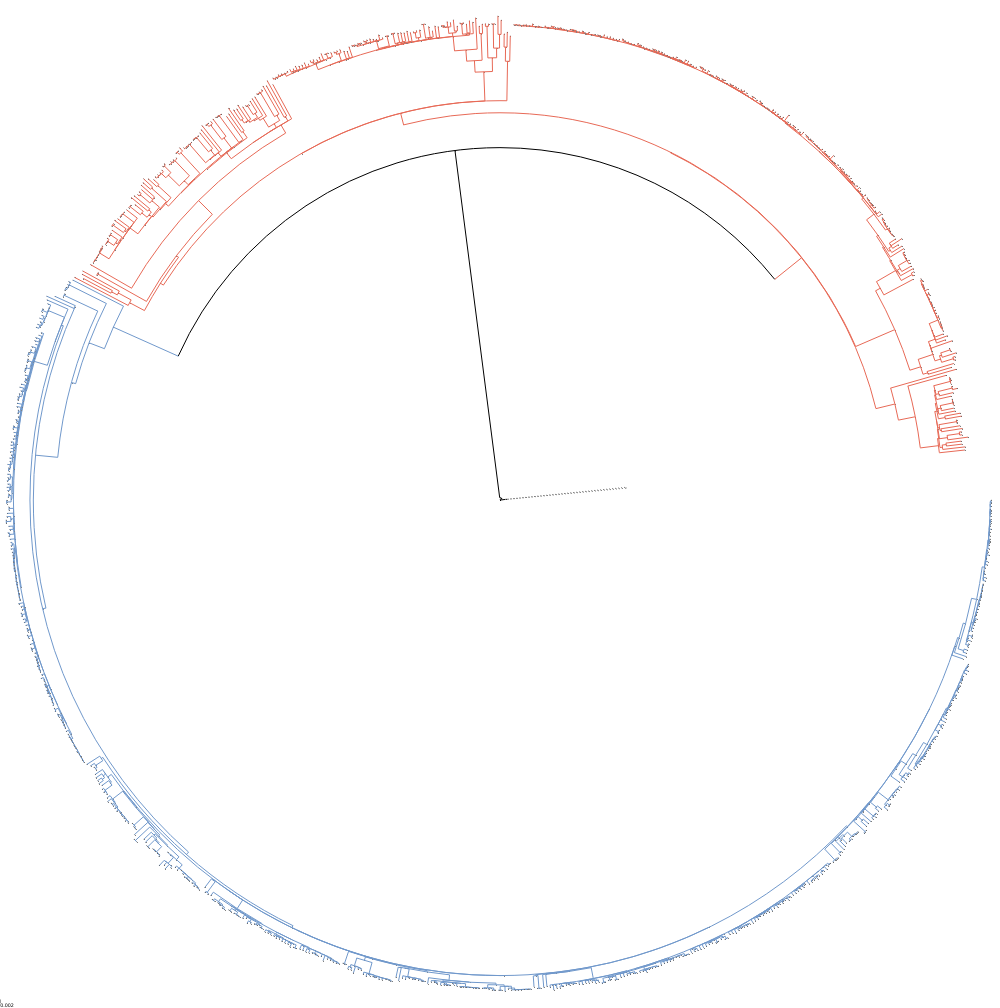

In [34]:

TGENSR_Gubbins_Tree.render("./TGENSR_937CI_GCE_Results/TGENSR.937CI.PhyloViz.ByLin.png", w = 1000, tree_style = ts_IQ_FullCirc)
TGENSR_Gubbins_Tree.render("./TGENSR_937CI_GCE_Results/TGENSR.937CI.PhyloViz.ByLin.pdf", w = 1000, tree_style = ts_IQ_FullCirc)
TGENSR_Gubbins_Tree.render("%%inline", w = 1000, tree_style = ts_IQ_FullCirc)

# TO DO: Output to "./TGENSR_937CI_GCE_Results/" as well

## Viz branches w/ putative events on the`TGEN-936-SR` phylogeny - `350 degree circle`

In [35]:
!mkdir ./TGENSR_937CI_GCE_Results/ 

mkdir: cannot create directory ‘./TGENSR_937CI_GCE_Results/’: File exists


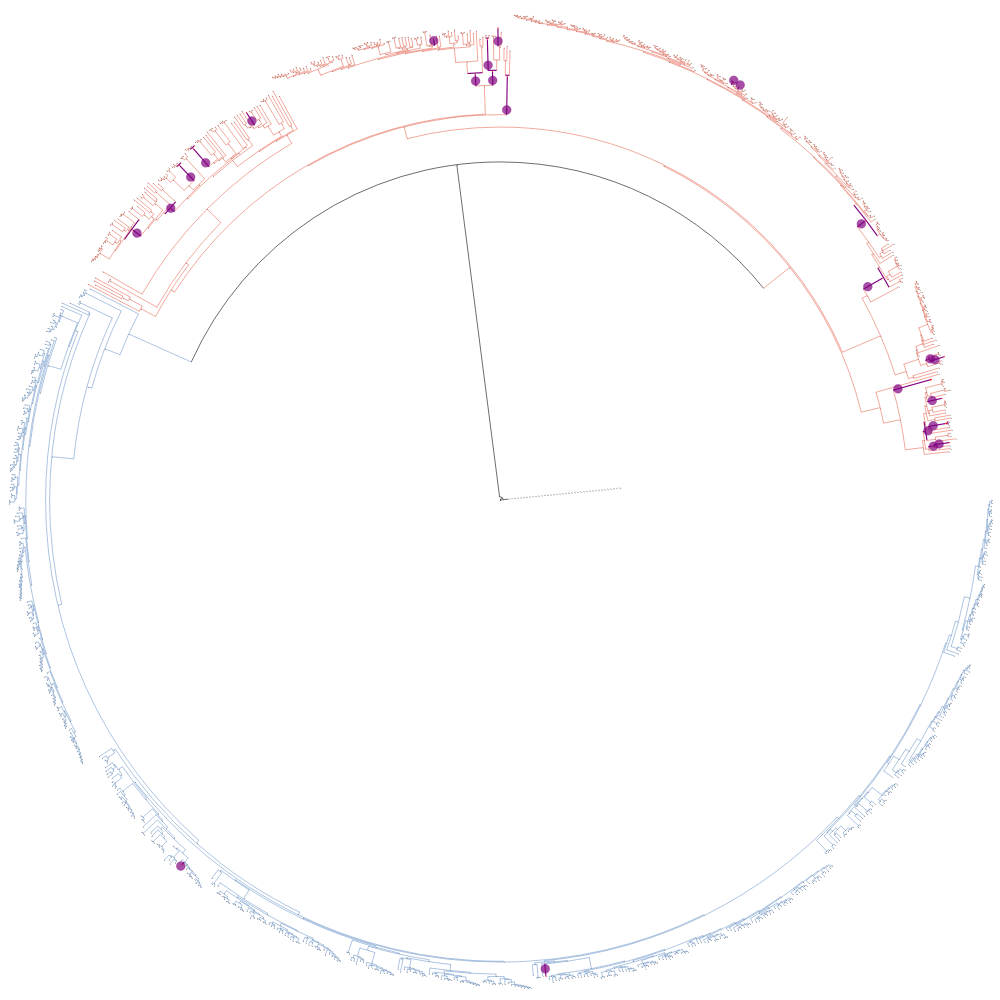

In [36]:
Tree_NumEvents_Labeled = labelNodesByNumEvents_V2(TGENSR_node_To_NumRecombEvents, TGENSR_Gubbins_Tree)

Tree_NumEvents_Labeled.render("./TGENSR_937CI_GCE_Results/TGENSR.937CI.PhyloViz.LabelGCEBranches.png", w = 1000, tree_style = ts_5_FullCirc)
Tree_NumEvents_Labeled.render("./TGENSR_937CI_GCE_Results/TGENSR.937CI.PhyloViz.LabelGCEBranches.pdf", w = 1000, tree_style = ts_5_FullCirc)
Tree_NumEvents_Labeled.render("%%inline", w = 1000, tree_style = ts_5_FullCirc)

# TO DO: Output to "./TGENSR_937CI_GCE_Results/" as well

In [37]:
# Tree_NumEvents_Labeled = labelNodesByNumEvents(TGENSR_node_To_NumRecombEvents, TGENSR_Gubbins_Tree)

# Tree_NumEvents_Labeled.render("%%inline", w = 1000, tree_style = ts_5_FullCirc)

## Viz `TGEN-936-SR` phylogeny with branches colored by MTBC Lineage - `180 degree circle`

In [38]:
#TGENSR_Gubbins_Tree.render("%%inline", w = 800, tree_style = ts_ColLin_circ)

## Viz branches w/ putative events on the`TGEN-936-SR` phylogeny - `180 degree circle`

In [39]:
# Tree_NumEvents_Labeled = labelNodesByNumEvents(TGENSR_node_To_NumRecombEvents, TGENSR_Gubbins_Tree)

# Tree_NumEvents_Labeled.render("%%inline", w = 1000, tree_style = ts_5_HalfCirc)

### Test the function to label specific "target" branches within a phylogeny

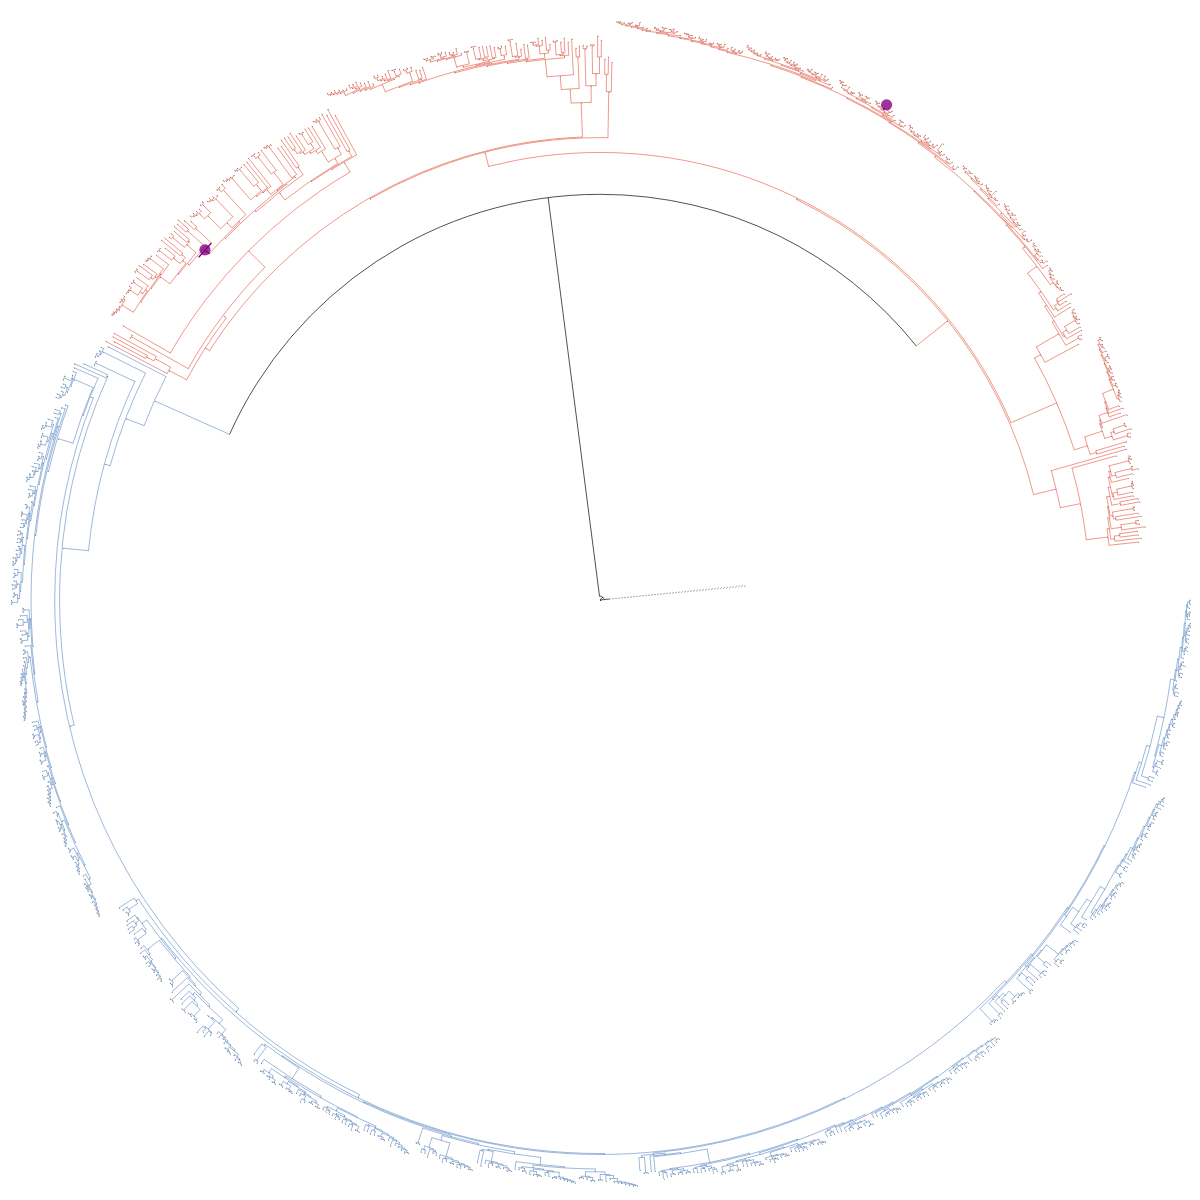

In [40]:
Tree_BranchLabeled_T1 =  highlight_TargetNodes_V3(["internal_986", "SRR6807674"],
                                                  TGENSR_Gubbins_Tree,
                                                  node_To_PrimaryLin_Dict)

Tree_BranchLabeled_T1.render("%%inline", w = 1200, tree_style = ts_5_FullCirc)

# Highlight the branch within the phylogeny for each of the 27 putative gene conversion events

In [41]:
TargetColn = ["EventID","Overlap_Genes", "Lineage", "HHR_Count", "HHR_Ovrlap", "Parent_Node", "Child_Node", "start_1based", "end_1based", "snp_count",]   


In [42]:
!mkdir ./TGENSR_937CI_GCE_VizEachEventOnPhylo/

mkdir: cannot create directory ‘./TGENSR_937CI_GCE_VizEachEventOnPhylo/’: File exists


In [43]:
!mkdir ./TGENSR_937CI_GCE_VizEachEventOnPhylo/

for i, row in TGENSR_GRE_DF.iterrows():

    i_EventID     = row["EventID"]
    i_ParentNode  = row["Parent_Node"]
    i_ChildNode   = row["Child_Node"]
    i_OvrlapGenes = row["Overlap_Genes"]

    #print(row[TargetColn])

    Tree_BranchLabeled_T1 = highlight_TargetNodes_V3([i_ChildNode],
                                                      TGENSR_Gubbins_Tree,
                                                      node_To_PrimaryLin_Dict)

    ts_Custom_FullCirc = ETE.TreeStyle()
    ts_Custom_FullCirc.mode = "c" # draw tree in circular mode
    ts_Custom_FullCirc.arc_start = 0 #-180 # 0 degrees = 3 o'clock
    ts_Custom_FullCirc.arc_span = 355
    ts_Custom_FullCirc.show_leaf_name = False
    ts_Custom_FullCirc.show_branch_length = False
    ts_Custom_FullCirc.show_branch_support = False
    ts_Custom_FullCirc.show_scale = False #True
    ts_Custom_FullCirc.branch_vertical_margin = 2
    ts_Custom_FullCirc.rotation = 0 #90

    title_text = "\n".join([f"TGEN-937-SR - Highlight Branch for {i_EventID}", 
                            f"BranchID = {i_ParentNode} -> {i_ChildNode}", 
                            f"Overlapping Genes = {i_OvrlapGenes}"])
    print(title_text)
    title_face = TextFace(title_text,
                          fsize=40, bold=True)

    ts_Custom_FullCirc.title.add_face(title_face, column=0)
    
    #Tree_BranchLabeled_T1.render("%%inline", w = 1000, tree_style = ts_5_FullCirc)
    Z = Tree_BranchLabeled_T1.render(f"./TGENSR_937CI_GCE_VizEachEventOnPhylo/TGEN-937-SR.CircPhylo.Highlight_{i_EventID}.pdf", w = 1200, tree_style = ts_Custom_FullCirc)     
    Z = Tree_BranchLabeled_T1.render(f"./TGENSR_937CI_GCE_VizEachEventOnPhylo/TGEN-937-SR.CircPhylo.Highlight_{i_EventID}.png", w = 1200, tree_style = ts_Custom_FullCirc)     

    print("----------------\n\n\n")

mkdir: cannot create directory ‘./TGENSR_937CI_GCE_VizEachEventOnPhylo/’: File exists
TGEN-937-SR - Highlight Branch for Event_001
BranchID = internal_985 -> internal_986
Overlapping Genes = vapC25,vapB25
----------------



TGEN-937-SR - Highlight Branch for Event_002
BranchID = internal_1262 -> SRR6807674
Overlapping Genes = Rv0393
----------------



TGEN-937-SR - Highlight Branch for Event_003
BranchID = internal_1061 -> internal_1062
Overlapping Genes = vapB31,vapC31
----------------



TGEN-937-SR - Highlight Branch for Event_004
BranchID = internal_941 -> SRR6807728
Overlapping Genes = Rv0750
----------------



TGEN-937-SR - Highlight Branch for Event_005
BranchID = internal_1177 -> internal_1181
Overlapping Genes = Rv0750
----------------



TGEN-937-SR - Highlight Branch for Event_006
BranchID = internal_1505 -> SRR10397175
Overlapping Genes = Rv0979c,rpmF,PE_PGRS18
----------------



TGEN-937-SR - Highlight Branch for Event_007
BranchID = internal_943 -> internal_946
Overla

# Extras